# Evaluation Pipeline — Baseline Benchmark

Before measuring the *effect* of distractors, we need a clean baseline aka what accuracy and cost does each model achieve on factual QA with no perturbation. This notebook runs the eval pipeline on 20 HotpotQA-style questions and reports accuracy, latency, and cost-per-correct.

**purpose:** Reproducible baseline table; demonstrates the caching eval infrastructure.

In [1]:
import os, asyncio, json, time, hashlib, re
from pathlib import Path
from dotenv import load_dotenv
load_dotenv("../../.env")

import pandas as pd
from anthropic import AsyncAnthropic

ac = AsyncAnthropic()

CACHE = Path(".cache/baseline") # this is where we will store cached API responses, so we don't have to call the API again for the same prompt/model combination
CACHE.mkdir(parents=True, exist_ok=True)

def cache_key(*parts) -> Path:
    h = hashlib.sha256(json.dumps(parts, sort_keys=True).encode()).hexdigest()[:16]
    return CACHE / f"{h}.json"

async def call(prompt, model, max_tokens=128):
    k = cache_key(prompt, model, max_tokens)
    if k.exists():
        r = json.loads(k.read_text()); r["cache_hit"] = True; return r
    t0 = time.time()
    r = await ac.messages.create(model=model, max_tokens=max_tokens,
                                  messages=[{"role": "user", "content": prompt}])
    result = {"text": r.content[0].text, "in_tok": r.usage.input_tokens,
             "out_tok": r.usage.output_tokens, "latency": time.time() - t0, "cache_hit": False}
    k.write_text(json.dumps(result))
    return result

print("Eval pipeline ready.")

Eval pipeline ready.


In [2]:
# 20 clean factual questions (no distractors) , this is the baseline
EVAL_SET = [
    # Single-hop factual
    {"qid": "f01",  "q": "What is the capital of France?",               "gold": "Paris"},
    {"qid": "f02",  "q": "What is the capital of Australia?",            "gold": "Canberra"},
    {"qid": "f03",  "q": "What is the largest ocean on Earth?",          "gold": "Pacific"},
    {"qid": "f04",  "q": "What element has the chemical symbol Au?",      "gold": "Gold"},
    {"qid": "f05",  "q": "How many bones are in the adult human body?",   "gold": "206"},
    {"qid": "f06",  "q": "What year did World War II end?",               "gold": "1945"},
    {"qid": "f07",  "q": "What is the speed of light in km/s?",           "gold": "299792"},
    {"qid": "f08",  "q": "Who wrote Pride and Prejudice?",                "gold": "Austen"},
    {"qid": "f09",  "q": "What is the chemical formula for water?",       "gold": "H2O"},
    {"qid": "f10",  "q": "What planet is closest to the Sun?",            "gold": "Mercury"},
    # Multi-hop (harder)
    {"qid": "m01",  "q": "What country has both the Eiffel Tower and the Louvre?", "gold": "France"},
    {"qid": "m02",  "q": "What language is spoken in the country that contains Machu Picchu?", "gold": "Spanish"},
    {"qid": "m03",  "q": "What ocean does the Amazon River drain into?",   "gold": "Atlantic"},
    {"qid": "m04",  "q": "What is the capital of the country where the Colosseum is?", "gold": "Rome"},
    {"qid": "m05",  "q": "What gas do plants absorb during photosynthesis?", "gold": "carbon dioxide"},
    {"qid": "m06",  "q": "Who painted the Sistine Chapel ceiling?",        "gold": "Michelangelo"},
    {"qid": "m07",  "q": "What is the longest river in Africa?",           "gold": "Nile"},
    {"qid": "m08",  "q": "How many sides does a hexagon have?",            "gold": "6"},
    {"qid": "m09",  "q": "What is the atomic number of carbon?",           "gold": "6"},
    {"qid": "m10",  "q": "In what year did the Berlin Wall fall?",         "gold": "1989"},
]

MODELS = ["claude-haiku-4-5", "claude-sonnet-4-6"]
PRICE  = {  # USD per 1M tokens
    "claude-haiku-4-5":  {"in": 1.00, "out": 5.00},
    "claude-sonnet-4-6": {"in": 3.00, "out": 15.00},
    "claude-opus-4-8":   {"in": 5.00, "out": 25.00},
}

def is_correct(gold, response):
    return gold.lower().strip() in response.lower()

async def run_baseline():
    tasks = [(item, model)
             for item in EVAL_SET
             for model in MODELS]
    async def _one(item, model):
        prompt = f"Answer in 1-3 words: {item['q']}"
        r = await call(prompt, model)
        return {
            "qid": item["qid"], "model": model, "gold": item["gold"],
            "response": r["text"], "correct": is_correct(item["gold"], r["text"]),
            "in_tok": r["in_tok"], "out_tok": r["out_tok"],
            "latency": r["latency"], "cache_hit": r["cache_hit"],
        }
    return await asyncio.gather(*[_one(item, model) for item, model in tasks])

rows = await run_baseline()
df = pd.DataFrame(rows)
print(f"Ran {len(df)} evaluations ({df.cache_hit.sum()} from cache)")

Ran 40 evaluations (20 from cache)


In [27]:
def cost(row):
    pr = PRICE.get(row["model"])
    if pr is None:
        print(f"Warning: no price entry for {row['model']!r}, cost set to 0")
        return 0.0
    return (row["in_tok"] * pr["in"] + row["out_tok"] * pr["out"]) / 1e6

df["cost_usd"] = df.apply(cost, axis=1)

summary = df.groupby("model").agg(
    accuracy=("correct", "mean"),
    avg_latency_s=("latency", "mean"),
    total_cost_usd=("cost_usd", "sum"),
    n_correct=("correct", "sum"),
    n_total=("correct", "count"),
).round(4)
summary["cost_per_correct_usd"] = (summary["total_cost_usd"] / summary["n_correct"]).round(6)

print(summary[["accuracy", "avg_latency_s", "total_cost_usd", "cost_per_correct_usd"]].to_string())

# Questions where models disagree (most informative)
pivot = df.pivot_table(index="qid", columns="model", values="correct", aggfunc="first")
if len(MODELS) >= 2:
    m1, m2 = MODELS[0], MODELS[1]
    disagree = pivot[pivot[m1] != pivot[m2]] if m1 != m2 else pivot.head(0)
    print(f"\nDisagreements: {len(disagree)} questions")
    print(F"Let;s see what the models answered for these questions:")
    print(f"m1 ({m1}) answers:\n{df[df['model'] == m1][['qid', 'response']].set_index('qid').loc[disagree.index]['response'].tolist()}")
    print(f"m2 ({m2}) answers:\n{df[df['model'] == m2][['qid', 'response']].set_index('qid').loc[disagree.index]['response'].tolist()}")

    print(f"\nDisagreements details:")
    for qid in disagree.index:
        q = next(item["q"] for item in EVAL_SET if item["qid"] == qid)
        r1 = df[(df["model"] == m1) & (df["qid"] == qid)]["response"].values[0]
        r2 = df[(df["model"] == m2) & (df["qid"] == qid)]["response"].values[0]
        print(f"QID: {qid}, Question: {q}\n  {m1} answered: {r1}\n  {m2} answered: {r2}\n")

    print(f"Questions first model answered wrong were:  {pivot[pivot[m1] == False].index.tolist()}")
    print(f"which are in plain english: {[next(item['q'] for item in EVAL_SET if item['qid'] == qid) for qid in pivot[pivot[m1] == False].index.tolist()]}")
    print(f"The model answered for these questions:\n{df[df['model'] == m1][['qid', 'response']].set_index('qid').loc[pivot[pivot[m1] == False].index]['response'].tolist()}")
    print(f"Questions second model answered wrong were: {pivot[pivot[m2] == False].index.tolist()}")
    print(f"which are in plain english: {[next(item['q'] for item in EVAL_SET if item['qid'] == qid) for qid in pivot[pivot[m2] == False].index.tolist()]}")
    print(f"The model answered for these questions:\n{df[df['model'] == m2][['qid', 'response']].set_index('qid').loc[pivot[pivot[m2] == False].index]['response'].tolist()}")

                   accuracy  avg_latency_s  total_cost_usd  cost_per_correct_usd
model                                                                           
claude-haiku-4-5       0.80         4.4642          0.0012              0.000075
claude-sonnet-4-6      0.85         3.0156          0.0037              0.000218

Disagreements: 1 questions
Let;s see what the models answered for these questions:
m1 (claude-haiku-4-5) answers:
['Six.']
m2 (claude-sonnet-4-6) answers:
['**6**']

Disagreements details:
QID: m09, Question: What is the atomic number of carbon?
  claude-haiku-4-5 answered: Six.
  claude-sonnet-4-6 answered: **6**

Questions first model answered wrong were:  ['f07', 'f09', 'm08', 'm09']
which are in plain english: ['What is the speed of light in km/s?', 'What is the chemical formula for water?', 'How many sides does a hexagon have?', 'What is the atomic number of carbon?']
The model answered for these questions:
['300,000 km/s', 'H₂O', 'Six sides.', 'Six.']
Questions

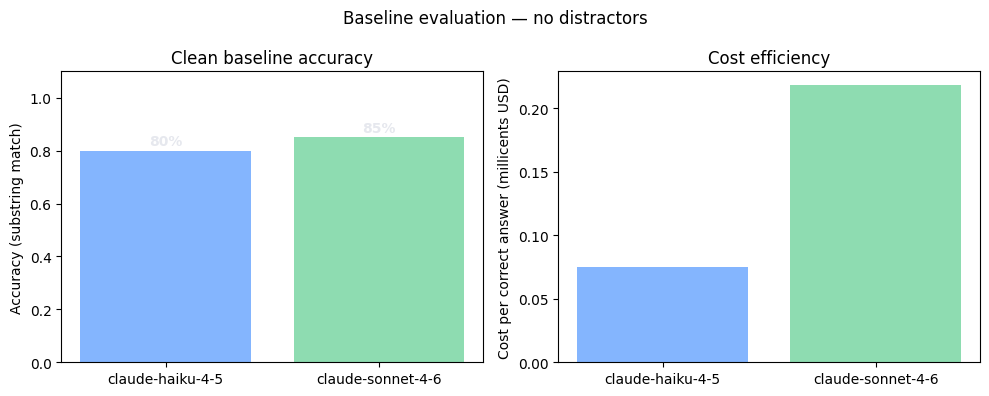


Model responses for each question:
model       claude-haiku-4-5   claude-sonnet-4-6            gold  correct_claude-haiku-4-5  correct_claude-sonnet-4-6
qid                                                                                                                  
f01                   Paris.               Paris           Paris                      True                       True
f02                 Canberra        **Canberra**        Canberra                      True                       True
f03            Pacific Ocean   **Pacific Ocean**         Pacific                      True                       True
f04                    Gold.            **Gold**            Gold                      True                       True
f05               206 bones.       **206 bones**             206                      True                       True
f06                     1945            **1945**            1945                      True                       True
f07             300,

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = summary.index.tolist()
colors = ["#6ea8fe", "#7ad6a4"]

axes[0].bar(models, summary["accuracy"], color=colors, alpha=0.85)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy (substring match)")
axes[0].set_title("Clean baseline accuracy")
for i, (m, acc) in enumerate(zip(models, summary["accuracy"])):
    axes[0].text(i, acc + 0.02, f"{acc:.0%}", ha="center", fontweight="bold", color="#e6e8ee")

axes[1].bar(models, summary["cost_per_correct_usd"] * 1000, color=colors, alpha=0.85)
axes[1].set_ylabel("Cost per correct answer (millicents USD)")
axes[1].set_title("Cost efficiency")

plt.suptitle("Baseline evaluation — no distractors", fontsize=12)
plt.tight_layout()
plt.savefig("baseline_eval.png", dpi=150, bbox_inches="tight")
plt.show()

answer_table = df.pivot_table(index="qid", columns="model", values="response", aggfunc="first")
answer_table["gold"] = df.groupby("qid")["gold"].first()
answer_table["correct_" + MODELS[0]] = df[df["model"] == MODELS[0]].set_index("qid")["correct"]
answer_table["correct_" + MODELS[1]] = df[df["model"] == MODELS[1]].set_index("qid")["correct"]

print("\nModel responses for each question:")
print(answer_table.to_string())

## Key Finding

This is the **n=0 anchor point** for the phase diagram. All distractor experiments measure accuracy relative to this baseline. A model that scores 90% here but drops to 30% at n=5 distractors has a much sharper phase transition than one that drops from 70% to 50%.

**Connection to main project:** These numbers become the leftmost column of the phase diagram heatmap. The cost-per-correct metric is a practitioner-facing output: it quantifies how much the distractor degradation costs in real money, not just accuracy points.

NOTE on theory: 
You ran model A and model B on 50 questions each. A got 36 right (72%), B got 34 right (68%). You write "A is better by 4 points."

  But 72% is not a fixed truth — it's an estimate from 50 noisy coin flips. The question is: how wide is the uncertainty around that estimate?

  For a binary outcome (right/wrong), the standard error of an accuracy estimate is:
  
  SE = sqrt(p * (1 - p) / n)

  Plug in p=0.72, n=50:
  
  SE = sqrt(0.72 * 0.28 / 50) = sqrt(0.004032) ≈ 0.063

  So 6.3 percentage points of uncertainty in one direction. A 95% confidence interval is roughly ±2 SE, so ±13 points. Your measured accuracy of 72% actually means "somewhere between 59% and 85%."

  Model B's 68% means "somewhere between 55% and 81%."
  
  Those ranges massively overlap. The true accuracy of A could be 61% and B could be 79% — i.e. B is actually better — and your experiment would still have produced those numbers by chance.
  
  The 4-point gap is smaller than your measurement error. You can't see a 4-point signal through 13 points of noise. It's like trying to measure whether a table is 1mm longer using a ruler with centimetre markings.
  
  Why n=50 is the culprit: SE shrinks as 1/√n. To get ±4 point CIs (so a 4-point gap is detectable), you need n ≈ 600 samples. Most ML papers use far fewer and report differences that are pure noise.

On hotpotqa:

A question answering benchmark where questions require two or more reasoning steps across multiple documents to answer.

  Example:

  ▎ "What nationality is the director of the film that won the 1972 Palme d'Or?"

  To answer this you need to:
  1. Look up which film won the 1972 Palme d'Or → The Working Class Goes to Heaven
  2. Look up who directed it → Elio Petri
  3. Look up Petri's nationality → Italian

  A single paragraph doesn't contain the answer — you have to chain facts across documents.


# FINAL observations



Both models produced correct answers for all of the questions, and all agreed. More than anything. above results prove the difficulty of creating a uniform benchmark for factual (and especially numerical) answers, especially in processing how theyre presented, and their accuracy